In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch import loggers as pl_loggers
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from torchvision.transforms import v2
import torchvision
from torchvision.io import read_image
from torch.utils.data import DataLoader
from torchgeo.datasets import RasterDataset, NonGeoDataset, IntersectionDataset, stack_samples, unbind_samples, random_bbox_assignment
from torchgeo.samplers import RandomGeoSampler, RandomBatchGeoSampler, GridGeoSampler
from torchgeo.datamodules import GeoDataModule
from torchgeo.datasets.utils import rgb_to_mask
import rasterio
from torchinfo import summary
import os
import re
import shutil
import kornia.augmentation as K
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from segmentation_models_pytorch.losses import DiceLoss, JaccardLoss, FocalLoss
import segmentation_models_pytorch as smp
import random

In [19]:
if torch.backends.mps.is_available():
	mps_device = torch.device("mps")
	x = torch.ones(1, device=mps_device)
	print(x)
elif torch.cuda.is_available():
	cuda_device = torch.device("cuda")
	x = torch.ones(1, device=cuda_device)
	print(x)

	print(torch.cuda.get_device_name(0))
	print('Memory Usage:')
	print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
	print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')
	
else:
	print("MPS device not found.")

tensor([1.], device='cuda:0')
NVIDIA GeForce RTX 3070 Laptop GPU
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [20]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_images(base_plot_size=4, overlay_tuples=[], cmap_labels=None, **images):
	n = len(images) + len(overlay_tuples)
	siz = base_plot_size * n
	fig, axs = plt.subplots(1,n, figsize=(siz, base_plot_size))

	for i, (name, image) in enumerate(images.items()):
		if n > 1:
			axs[i].set_title(name)
			axs[i].imshow(image)
			axs[i].axis('off')
		else:
			axs.set_title(name)
			axs.imshow(image)

	for j, overlay_tuple in enumerate(overlay_tuples):
		axs[i + j + 1].set_title(",".join(overlay_tuple))
		axs[i + j + 1].imshow(images[overlay_tuple[0]])
		axs[i + j + 1].imshow(images[overlay_tuple[1]], alpha=0.3)
		axs[i + j + 1].axis('off')
	
	if cmap_labels:
		legend_elements = [Patch(facecolor=v, label=k) for k, v in cmap_labels.items()]
		plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
		# plt.legend(handles=legend_elements)
	plt.tight_layout()
	plt.show()


def plot_overlay(image, mask, plot_size=4, cmap_labels=None):
	fig, ax = plt.subplots(1,1, figsize=(plot_size, plot_size))

	ax.imshow(image)
	ax.imshow(mask, alpha=0.3)
	ax.axis('off')

	if cmap_labels:
		legend_elements = [Patch(facecolor=v, label=k) for k, v in cmap_labels.items()]
		plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
	plt.tight_layout()



## Data loaders 

In [21]:
seg_map_cmap = [
	(255, 255, 255), # 0. Impervious Surfaces
  (0,0, 255), # 1. Building
  (0, 255, 255), # 2. Low Vegetation
  (0, 255, 0), # 3. Tree
  (255, 255, 0), # 4. Car
  (255, 0, 0), # 5. Clutter/background
]

seg_map_cmap_labels = {
	'0. Impervious Surfaces':(255, 255, 255),
	'1. Building': (0,0, 255),
	'2. Low Vegetation': (0, 255, 255),
	'3. Tree': (0, 255, 0),
	'4. Car': (255, 255, 0),
	'5. Clutter/background': (255, 0, 0),
}

for k in seg_map_cmap_labels:
  seg_map_cmap_labels[k] = tuple([v/255 for v in seg_map_cmap_labels[k]])


In [22]:
# Dataset root paths
postdam_path = '../datasets/isprs/Potsdam/'

In [23]:
# Postdam quick fix - add CRS info to segmentation maps

reprocess_segmentation = False

if reprocess_segmentation:
	postdam_source_img_names = [f for f in os.listdir(os.path.join(postdam_path, '2_Ortho_RGB')) if re.match('.*.tif',f)]

	for filename in postdam_source_img_names:
		target_filename = re.sub(r'_RGB.tif$', '_label.tif', filename)
		source_raster = rasterio.open(os.path.join(postdam_path, '2_Ortho_RGB', filename), 'r')
		
		target_raster = rasterio.open(os.path.join(postdam_path, '5_Labels_all', target_filename), 'r')
		h = target_raster.height # 6000
		w = target_raster.width # 6000
		count = target_raster.count # 3
		dtype = target_raster.dtypes[0] # 'uint8'
		data = target_raster.read()
		target_raster.close()
		
		with rasterio.open(
			os.path.join(postdam_path, '5_Labels_all', target_filename),
			'w',
			driver='GTiff',
			height=h,
			width=w,
			count=count,
			dtype=dtype,
			crs=source_raster.crs,
			transform=source_raster.transform,
		) as new_file:
			new_file.write(data)

	del data

In [24]:
def invserse_cmap(image, cmap):
  return torch.tensor(cmap)[image.numpy()].permute(2, 0, 1)

In [25]:
def global_augmentations(image, mask):
	if random.random() > 0.5:
		angle = np.random.randint(4) * 90
		image = v2.functional.rotate(image, angle)
		mask = v2.functional.rotate(mask, angle)
	
	if random.random() > 0.5:
		image = v2.functional.vflip(image)
		mask = v2.functional.vflip(mask)
	
	if random.random() > 0.5:
		image = v2.functional.hflip(image)
		mask = v2.functional.hflip(mask)
	return image, mask

class RGBLoader(RasterDataset):
	filename_glob = '*.tif'
	is_image=True
	separate_files=False

class SegmentationMapLoader(RasterDataset):
	filename_glob = '*.tif'
	is_image=False # False means is a segmentation mask
	separate_files=False
	seg_map_cmap=seg_map_cmap
	one_hot=False

	def __getitem__(self, query):
		item = super().__getitem__(query)
		item['mask'] = item['mask'].permute(1, 2, 0)
		
		mask = torch.zeros(item['mask'].shape[:2], dtype=torch.int64)
		for i, c in enumerate(self.seg_map_cmap):
			cmask = item['mask'] == torch.tensor(c)
			mask[cmask.all(axis=-1)] = i

		item['mask'] = F.one_hot(mask).permute(2, 0, 1) if self.one_hot else mask.unsqueeze(0)
		return item


In [26]:
# Data Augmentation transforms
images_transforms = v2.Compose([
  v2.Resize(size=256),
  # v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

segmentation_transforms = v2.Compose([v2.Resize(size=250, interpolation=torchvision.transforms.InterpolationMode.NEAREST_EXACT)])

postdam_img_dataset = RGBLoader(
  os.path.join(postdam_path, '2_Ortho_RGB'),
  # transforms=images_transforms
)
postdam_seg_map_dataset = SegmentationMapLoader(
  os.path.join(postdam_path, '5_Labels_all'),
  # transforms=segmentation_transforms
)

# dataset = postdam_img_dataset & postdam_seg_map_dataset # Intersection Dataset
dataset = IntersectionDataset(postdam_img_dataset, postdam_seg_map_dataset)

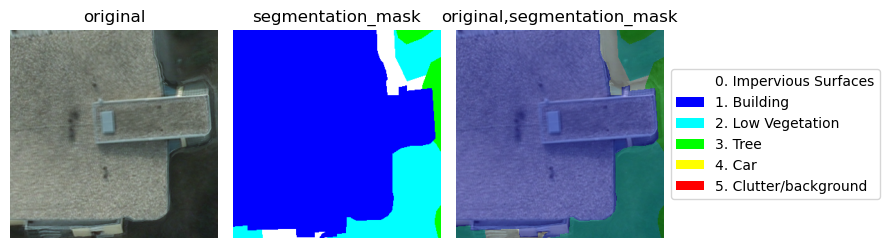

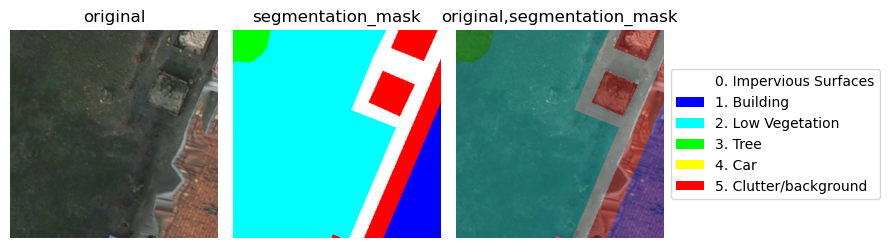

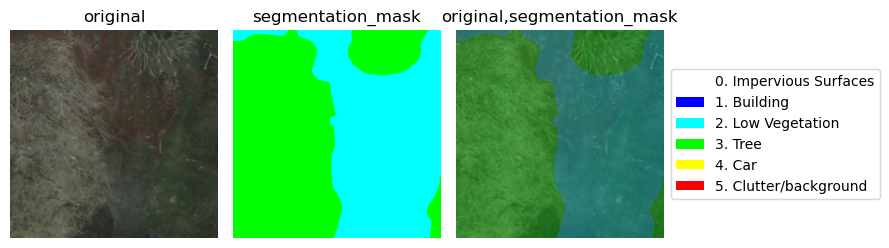

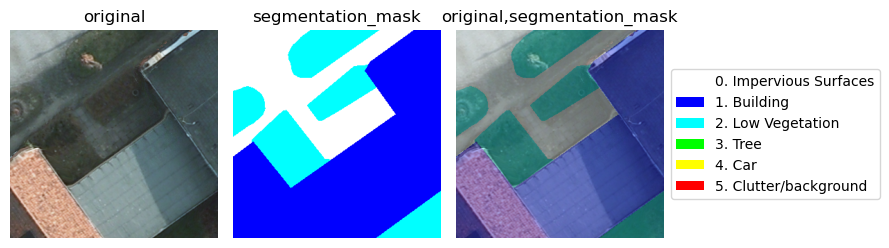

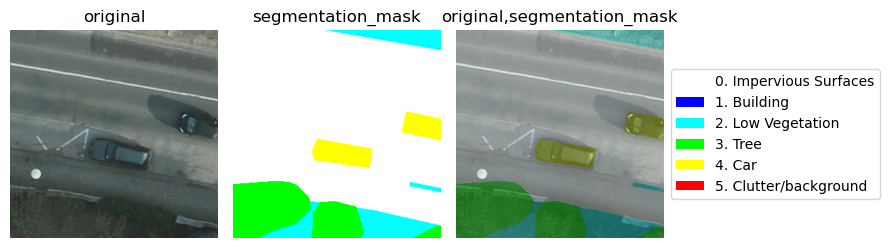

In [29]:
sampler = RandomGeoSampler(dataset, size=300, length=10) # patches of size 256, but resized by the transforms above
dataloader = DataLoader(dataset, sampler=sampler, collate_fn=stack_samples)

n=0
for sample in dataloader:
	if n==5: break

	image, gt = global_augmentations(sample['image'], sample['mask'])
	gt = invserse_cmap(gt.squeeze(), seg_map_cmap)

	plot_images(
		base_plot_size=3,
		overlay_tuples = [['original', 'segmentation_mask']],
		original=v2.ToPILImage(mode='RGB')(image.squeeze()/255),
		segmentation_mask=v2.ToPILImage(mode='RGB')(gt/255),
		cmap_labels=seg_map_cmap_labels
	)
	n+=1

In [30]:
sample['image'].shape, sample['mask'].shape

(torch.Size([1, 3, 300, 300]), torch.Size([1, 1, 300, 300]))

In [31]:
image.shape, gt.shape

(torch.Size([1, 3, 300, 300]), torch.Size([3, 300, 300]))

In [32]:
sample['crs']

[CRS.from_epsg(32633)]

In [33]:
sample['bbox']

[BoundingBox(minx=367695.304463923, maxx=367710.304463923, miny=5807976.644098898, maxy=5807991.644098898, mint=0.0, maxt=9.223372036854776e+18)]

In [34]:
sample['mask'].shape

torch.Size([1, 1, 300, 300])

Lightning DataModule (GeoDataModule)

## Model (U-Net)

**Paper:** https://arxiv.org/pdf/1505.04597v1

**Related Readings:**
* Skip connections: https://theaisummer.com/skip-connections/
* Skip connections(cont.): https://www.analyticsvidhya.com/blog/2021/08/all-you-need-to-know-about-skip-connections/
* Segmentation Intro: https://www.jeremyjordan.me/semantic-segmentation/
* Satellital Imagery segmentation: https://towardsdatascience.com/u-net-for-semantic-segmentation-on-unbalanced-aerial-imagery-3474fa1d3e56/
* Convolution visualization: https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md (useful to see how the upsampling transposed convolution works)
* Batch Norm: https://towardsdatascience.com/batch-norm-explained-visually-how-it-works-and-why-neural-networks-need-it-b18919692739/

Other Implementations:
* https://github.com/milesial/Pytorch-UNet

Unet Architecture looks like this:

<img src="https://towardsdatascience.com/wp-content/uploads/2021/10/1eQLQo43suhzuHslqy-LL3g.png" width="800">

The key elements of a step in the "contraction" path of the architecture are:
* Double 3x3 convolutions at every step
* After the double convolutions, it has a 2x2 max pooling with stride 2 for downsampling
* After each downsample, the number of channels are doubled

The key elements of a step in the "expansive" path of the architecture are:
* 2x2 up-convolution that halves the number of channels (upscaling)
* We concatenate the corresponding feature maps of the contraction path to the upscaled maps.
  * Keep in mind that the concatenated maps are cropped because we miss border pixels on each convolution
  * Some authors handle the border issues by extending/reflecting/padding the images.
* We apply double 3x3 convolutions before the next upscaling.

At the end we apply a 1x1 convolution layer to map the resulting feature maps to the desired number of classes

---
---
---
**For this Implementation we use a pretrained version of U-NET from segmentationmodels: https://smp.readthedocs.io/en/latest/index.html**

In [35]:
# Double convolution block
class BlockConvolution(nn.Module):
	def __init__(self, in_channels, out_channels):
		super().__init__()
		self.model = nn.Sequential(
			nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1), # padding to avoid border issues
			nn.BatchNorm2d(out_channels), # Not required in the base architecture, but according to what we've read, it is useful to avoid gradient vanishing problems, stabilizes learning, etc.
			nn.ReLU(),
			nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding=1),
			nn.BatchNorm2d(out_channels),
			nn.ReLU()
		)
	
	def forward(self, x):
		return self.model(x)


class DownBlock(nn.Module):
	def __init__(self, in_channels, out_channels):
		super().__init__()
		self.model = nn.Sequential(
			nn.MaxPool2d(2),
			BlockConvolution(in_channels, out_channels)
		)
	
	def forward(self, x):
		return self.model(x)


class UpBlock(nn.Module):
	def __init__(self, in_channels, out_channels):
		super().__init__()
		# Reduce the number of in_channels by half and upscale image by twice de dimension
		# Conv (half of the in_channels come from the skip connections and the other half from the upscale)
		self.upscale = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
		self.block_conv = BlockConvolution(in_channels, out_channels)

	def forward(self, x, x_skip):
		# x_skip are the weights of the corresponding down layer
		# Upscale
		x = self.upscale(x)
		
		# Pad upscaled (if necessary?)
		diffY = x_skip.size()[2] - x.size()[2]
		diffX = x_skip.size()[3] - x.size()[3]
		x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
		
		# Concat
		x = torch.cat([x_skip, x], dim=1)
		return self.block_conv(x)


class UNET(nn.Module):
	def __init__(self, in_channels, n_classes, initial_convolutions=64, max_contraction_depth=4):
		super().__init__()

		conv_list = [initial_convolutions]
		for i in range(max_contraction_depth):
			conv_list.append(conv_list[-1] * 2)

		contraction_layers = [BlockConvolution(in_channels, conv_list[0])]
		contraction_layers = contraction_layers + [DownBlock(conv_list[i], conv_list[i + 1]) for i in range(max_contraction_depth)]
		self.contraction_layers = nn.ModuleList(contraction_layers)

		expansion_layers = [UpBlock(conv_list[i], conv_list[i - 1]) for i in range(max_contraction_depth, 0, -1)]
		self.expansion_layers = nn.ModuleList(expansion_layers)
		
		# self.contraction_layers = nn.ModuleList([
		# 	BlockConvolution(in_channels, 64), # skips to D
		# 	DownBlock(64, 128), # skips to C
		# 	DownBlock(128, 256), # skips to B
		# 	DownBlock(256, 512), # skips to A
		# 	DownBlock(512, 1024), 
		# ])
		# self.expansion_layers = nn.ModuleList([
		# 	UpBlock(1024, 512), # A
		# 	UpBlock(512, 256),  # B
		# 	UpBlock(256, 128), # C
		# 	UpBlock(128, 64) # D
		# ])
		self.out_layer = nn.Conv2d(initial_convolutions, n_classes, kernel_size=1) # Logits

	def forward(self, x):
		# Contraction
		x_c = [self.contraction_layers[0](x)]
		for f in self.contraction_layers[1:]:
			x_c.append(f(x_c[-1]))

		# Expansion
		x = self.expansion_layers[0](x_c[-1], x_c[-2]) # (x_to_upscale, skip_values)
		for i, f in enumerate(self.expansion_layers[1:]):
			skip_idx = len(self.contraction_layers) - 3 - i 
			x = f(x, x_c[skip_idx])
		
		x = self.out_layer(x)
		return x

In [36]:
# Test forward
test = UNET(in_channels=3, n_classes=len(seg_map_cmap), initial_convolutions=64, max_contraction_depth=4)
test_in = torch.randn(2, 3, 128, 128)
test_out = test(test_in)

print(test_in.shape)
print(test_out.shape)
print("n_classes:", len(seg_map_cmap))

print(summary(test, (1, 3, 128, 128), depth=3, device="cpu"))

del test, test_in, test_out

torch.Size([2, 3, 128, 128])
torch.Size([2, 6, 128, 128])
n_classes: 6
Layer (type:depth-idx)                             Output Shape              Param #
UNET                                               [1, 6, 128, 128]          --
├─ModuleList: 1-1                                  --                        --
│    └─BlockConvolution: 2-1                       [1, 64, 128, 128]         --
│    │    └─Sequential: 3-1                        [1, 64, 128, 128]         38,976
│    └─DownBlock: 2-2                              [1, 128, 64, 64]          --
│    │    └─Sequential: 3-2                        [1, 128, 64, 64]          221,952
│    └─DownBlock: 2-3                              [1, 256, 32, 32]          --
│    │    └─Sequential: 3-3                        [1, 256, 32, 32]          886,272
│    └─DownBlock: 2-4                              [1, 512, 16, 16]          --
│    │    └─Sequential: 3-4                        [1, 512, 16, 16]          3,542,016
│    └─DownBlock: 2-5  

Testing inouts of loss functions and defining dice loss and 

target shape; torch.Size([1, 300, 300])
target unique; tensor([0, 1, 2])
target_onehot shape: torch.Size([1, 6, 300, 300])
target_onehot unique: tensor([0, 1])
crossentropy: tensor(1.0436)
dice: tensor(0.2982)
jaccard: tensor(0.3724)


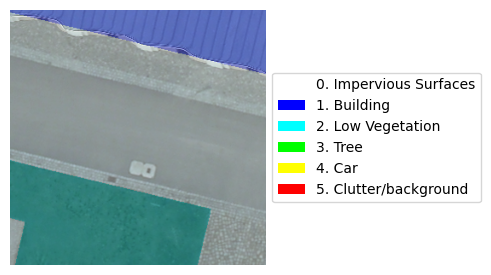

crossentropy: tensor(1.9102)
dice: tensor(0.4040)
jaccard: tensor(0.4469)


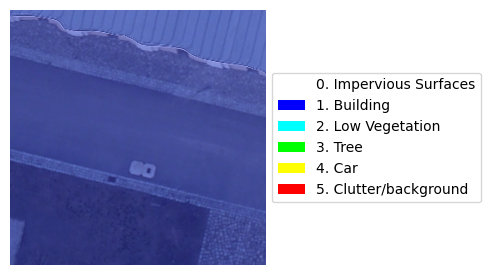

In [37]:
image, target = sample['image'], sample['mask'].squeeze(0)

# target = torch.ones_like(target) * 5

gt_color = invserse_cmap(target.squeeze(0), seg_map_cmap)
target_onehot = F.one_hot(target, num_classes=len(seg_map_cmap)).permute(0, 3, 1, 2)

print("target shape;", target.shape) # N_batches, h, w
print("target unique;", target.unique()) # Classes with interger values between [0, N_classes]
print("target_onehot shape:", target_onehot.shape) # N_batches, N_classes, h, w
print("target_onehot unique:", target_onehot.unique()) # One hot representation, only zeroes and ones
print("crossentropy:", F.cross_entropy(target_onehot.float(), target))

dice = DiceLoss(mode='multiclass')
print("dice:", dice(target_onehot.float(), target))

jaccard = JaccardLoss(mode='multiclass')
print("jaccard:", jaccard(target_onehot.float(), target))



plot_overlay(
	v2.ToPILImage(mode='RGB')(image.squeeze()/255),
	v2.ToPILImage(mode='RGB')(gt_color/255),
  plot_size=5,
  cmap_labels=seg_map_cmap_labels
)
plt.show()

# tmp_target = target.clone()
# tmp_target[tmp_target == 2] = 0
tmp_target = torch.ones_like(target) * 1

gt_color = invserse_cmap(tmp_target.squeeze(0), seg_map_cmap)
tmp_target_onehot = F.one_hot(tmp_target, num_classes=len(seg_map_cmap)).permute(0, 3, 1, 2)

print("crossentropy:", F.cross_entropy(tmp_target_onehot.float(), target))

dice = DiceLoss(mode='multiclass')
print("dice:", dice(tmp_target_onehot.float(), target))

jaccard = JaccardLoss(mode='multiclass')
print("jaccard:", jaccard(tmp_target_onehot.float(), target))

plot_overlay(
	v2.ToPILImage(mode='RGB')(image.squeeze()/255),
	v2.ToPILImage(mode='RGB')(gt_color/255),
  plot_size=5,
  cmap_labels=seg_map_cmap_labels
)
plt.show()


Define Lightning Module and DataModule

In [38]:
class UNETModel(L.LightningModule):
	def __init__(
		self,
		image_size=256,
		cmap=seg_map_cmap,
		lr=1e-3,
		epochs=30,
	):
		super().__init__()
		# self.model = UNET(in_channels=3, n_classes=len(cmap))
		self.model = UNET(in_channels=3, n_classes=len(cmap), initial_convolutions=64, max_contraction_depth=4)

		self.focal_loss = FocalLoss(mode='multiclass', gamma=0)
		self.dice_loss = DiceLoss(mode='multiclass')
		# self.crossentropy_loss = nn.CrossEntropyLoss()
		
		self.cmap = cmap
		self.n_classes = len(cmap)
		self.image_size=image_size
		self.lr = lr
		self.epochs=epochs
		self.save_hyperparameters()

	def forward(self, x):
		return self.model(x)
		
	def training_step(self, batch, batch_idx):
		x = batch['image'] / 255 # normalize, it was not normalized, and I don't wan't to fiddle more with the transforms, I'm tired!!!!!
		y = batch['mask']
		
		print()
		print("-------------")
		print(x.shape, y.shape)
		
		# x, y = global_augmentations(x, y)
		
		y_pred = self(x)
		
		# print("----------------")
		# print("image shape", x.shape)
		# print("-----------")
		# print("mask shape", y.shape)
		# print("mask unique", y.unique())
		# print("-----------------")
		# print("y_pred shape", y_pred.shape)
		# print("y_pred max/min", y_pred.max(), y_pred.min())

		# focal = self.focal_loss(y_pred, y)
		dice = self.dice_loss(y_pred, y)
		crossentropy = self.focal_loss(y_pred, y)
		loss = dice + crossentropy
		
		# self.log("train_focal_loss", focal, prog_bar=True, on_step=False, on_epoch=True)
		self.log("train_dice_loss", dice, prog_bar=True, on_step=False, on_epoch=True)
		self.log("train_crossentropy_loss", crossentropy, prog_bar=True, on_step=False, on_epoch=True)
		self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
		return loss

	def validation_step(self, batch, batch_idx):
		x = batch['image'] / 255
		y = batch['mask']
		y_pred = self(x)
		
		# focal = self.focal_loss(y_pred, y)
		dice = self.dice_loss(y_pred, y)
		crossentropy = self.focal_loss(y_pred, y)
		loss = dice + crossentropy

		# self.log("val_focal_loss", focal, prog_bar=True, on_step=False, on_epoch=True)
		self.log("val_dice_loss", dice, prog_bar=True, on_step=False, on_epoch=True)
		self.log("val_crossentropy_loss", crossentropy, prog_bar=True, on_step=False, on_epoch=True)
		self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
		return loss
	
	@torch.no_grad()
	def test_step(self, batch, batch_idx):
		x = batch['image'] / 255
		y = batch['mask']
		y_pred = self(x)
		
		# focal = self.focal_loss(y_pred, y)
		dice = self.dice_loss(y_pred, y)
		crossentropy = self.focal_loss(y_pred, y)
		loss = dice + crossentropy
		
		#self.log("test_focal_loss", focal, prog_bar=True, on_step=False, on_epoch=True)
		self.log("test_dice_loss", dice, prog_bar=True, on_step=False, on_epoch=True)
		self.log("test_crossentropy_loss", crossentropy, prog_bar=True, on_step=False, on_epoch=True)
		self.log("test_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
		return loss
	
	def on_train_epoch_start(self):
		# Log the learning rate
		optimizer = self.trainer.optimizers[0]
		lr = optimizer.param_groups[0]['lr']
		self.log('learning_rate', lr, on_epoch=True, prog_bar=True)

	def configure_optimizers(self):
		optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
		# optimizer = torch.optim.RMSprop(self.parameters(), lr=self.lr, weight_decay=1e-8, momentum=0.999, foreach=True)
		scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=8)  # goal: maximize Dice score

		return {
        "optimizer": optimizer,
        "lr_scheduler": {
            "scheduler": scheduler,
            "monitor": "val_loss",
            "frequency": 1
            # If "monitor" references validation metrics, then "frequency" should be set to a
            # multiple of "trainer.check_val_every_n_epoch".
        },
    }


In [39]:
class RGBLoader(RasterDataset):
	filename_glob = '*.tif'
	is_image=True
	separate_files=False

class SegmentationMapLoader(RasterDataset):
	filename_glob = '*.tif'
	is_image=False # False means is a segmentation mask
	separate_files=False
	seg_map_cmap=seg_map_cmap
	one_hot=False

	def __getitem__(self, query):
		item = super().__getitem__(query)
		item['mask'] = item['mask'].permute(1, 2, 0)
		
		mask = torch.zeros(item['mask'].shape[:2], dtype=torch.int64)
		for i, c in enumerate(self.seg_map_cmap):
			cmask = item['mask'] == torch.tensor(c)
			mask[cmask.all(axis=-1)] = i

		item['mask'] = F.one_hot(mask).permute(2, 0, 1) if self.one_hot else mask.unsqueeze(0)
		return item


class CustomGeoDataModule(GeoDataModule): # Geodamatodule extends from torch lightning DataModules
	def __init__(self, **kwargs):
		super().__init__(
			dataset_class=kwargs['dataset_class'],
			batch_size=kwargs['batch_size'],
			patch_size=kwargs['patch_size'],
			length=kwargs['length'],
			num_workers=kwargs['num_workers'],
			**kwargs['dataset_class_kwargs']
		)
		# keep in mind that super method will set kwargs object attribute as kwargs['dataset_class_kwargs']
		self.split_faction = kwargs.get('split_fraction', [0.6, 0.2, 0.2]) # train, validate, test
		self.seed = kwargs.get('seed')

	def setup(self, stage):
		# self.dataset = self.dataset_class(**self.kwargs)
		self.dataset = self.kwargs['dataset1'] & self.kwargs['dataset2']

		generator = torch.Generator().manual_seed(self.seed)
		(self.train_dataset, self.val_dataset, self.test_dataset) = random_bbox_assignment(self.dataset, self.split_faction, generator)

		if stage in ["fit"]:
			self.train_batch_sampler = RandomBatchGeoSampler(self.train_dataset, self.patch_size, self.batch_size, self.length)
		if stage in ["fit", "validate"]:
			self.val_sampler = GridGeoSampler(self.val_dataset, self.patch_size, self.patch_size)
		if stage in ["test"]:
			self.test_sampler = GridGeoSampler(self.test_dataset, self.patch_size, self.patch_size)


## Training

In [40]:
patch_size = 300 # Patch size
sample_size = 500
batch_size = 16
n_workers = 4
split_fraction = [0.7, 0.1, 0.2] # train, validate, test


# Rescale factor
in_image_size = 256
out_image_size = 256
images_transforms = v2.Compose([
	v2.Resize(size=in_image_size),
])


segmentation_transforms = v2.Compose([
	v2.Resize(size=out_image_size, interpolation=torchvision.transforms.InterpolationMode.NEAREST_EXACT),
])

postdam_img_dataset = RGBLoader(os.path.join(postdam_path, '2_Ortho_RGB'), transforms=images_transforms)
postdam_seg_map_dataset = SegmentationMapLoader(os.path.join(postdam_path, '5_Labels_all'), transforms=segmentation_transforms)

datamodule = CustomGeoDataModule(
	dataset_class = IntersectionDataset,
	batch_size = batch_size, # GeoDataModule kwargs
	patch_size = patch_size, # GeoDataModule kwargs
	length = sample_size, # GeoDataModule kwargs
	num_workers = n_workers, # GeoDataModule kwargs
	dataset_class_kwargs = dict(
		dataset1 = postdam_img_dataset, # IntersectionDataset kwargs
		dataset2 = postdam_seg_map_dataset, # IntersectionDataset kwargs
		collate_fn = stack_samples, # IntersectionDataset kwargs
	),
	split_fraction=split_fraction,
	seed=54321,
)

In [41]:
lr = 1e-3
epochs = 500

model = UNETModel(
  image_size=in_image_size,
	cmap=seg_map_cmap,
	lr=lr,
	epochs=epochs,
)

summary(model.model, (1, 3, in_image_size, in_image_size), depth=4, device="cpu")

Layer (type:depth-idx)                             Output Shape              Param #
UNET                                               [1, 6, 256, 256]          --
├─ModuleList: 1-1                                  --                        --
│    └─BlockConvolution: 2-1                       [1, 64, 256, 256]         --
│    │    └─Sequential: 3-1                        [1, 64, 256, 256]         --
│    │    │    └─Conv2d: 4-1                       [1, 64, 256, 256]         1,792
│    │    │    └─BatchNorm2d: 4-2                  [1, 64, 256, 256]         128
│    │    │    └─ReLU: 4-3                         [1, 64, 256, 256]         --
│    │    │    └─Conv2d: 4-4                       [1, 64, 256, 256]         36,928
│    │    │    └─BatchNorm2d: 4-5                  [1, 64, 256, 256]         128
│    │    │    └─ReLU: 4-6                         [1, 64, 256, 256]         --
│    └─DownBlock: 2-2                              [1, 128, 128, 128]        --
│    │    └─Sequential: 3-

In [42]:
out_path = './training_unet/t_6/'
if not os.path.exists(out_path):
	os.makedirs(out_path)

logger = pl_loggers.CSVLogger(
	out_path,
	name='train_logs'
)

checkpoint_callback = ModelCheckpoint(
	every_n_epochs=1,
	dirpath=out_path,
	filename='{epoch}-{val_loss:.2f}-{train_loss:.2f}',
	save_last=True,
	save_top_k=5,
	monitor='val_loss',
	mode='min',
)

# early_stop_callback = EarlyStopping(
# 	monitor="val_loss",
# 	mode="min",
# 	patience=30,
# )

trainer = Trainer(
	max_epochs=epochs,
	accelerator='cuda',
	callbacks=[
		checkpoint_callback,
		# early_stop_callback
	],
	logger=logger,
	fast_dev_run=True
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


In [43]:
trainer.fit(model, datamodule)

You are using a CUDA device ('NVIDIA GeForce RTX 3070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type      | Params | Mode 
-------------------------------------------------
0 | model      | UNET      | 31.0 M | train
1 | focal_loss | FocalLoss | 0      | train
2 | dice_loss  | DiceLoss  | 0      | train
-------------------------------------------------
31.0 M    Trainable params
0         Non-trainable params
31.0 M    Total params
124.175   Total estimated model params size (MB)
98        Modules in train mode
0         Modules in eval mode


Epoch 0:   0%|          | 0/1 [00:00<?, ?it/s] 
-------------
torch.Size([16, 3, 256, 256]) torch.Size([16, 256, 256])
Epoch 0: 100%|██████████| 1/1 [00:02<00:00,  0.40it/s, val_dice_loss=0.852, val_crossentropy_loss=4.160, val_loss=5.010, learning_rate=0.001, train_dice_loss=0.857, train_crossentropy_loss=4.330, train_loss=5.190]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 0: 100%|██████████| 1/1 [00:02<00:00,  0.40it/s, val_dice_loss=0.852, val_crossentropy_loss=4.160, val_loss=5.010, learning_rate=0.001, train_dice_loss=0.857, train_crossentropy_loss=4.330, train_loss=5.190]


In [76]:
trainer.test(
  model=model,
  ckpt_path="last",
  datamodule=datamodule,
)

/home/edwmapa/miniconda3/envs/mlenv_nn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/checkpoint_connector.py:186: .test(ckpt_path="last") is set, but there is no last checkpoint available. No checkpoint will be loaded. HINT: Set `ModelCheckpoint(..., save_last=True)`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  5.84it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 test_crossentropy_loss      4.245257377624512
     test_dice_loss         0.8661952018737793
        test_loss            5.111452579498291
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_dice_loss': 0.8661952018737793,
  'test_crossentropy_loss': 4.245257377624512,
  'test_loss': 5.111452579498291}]

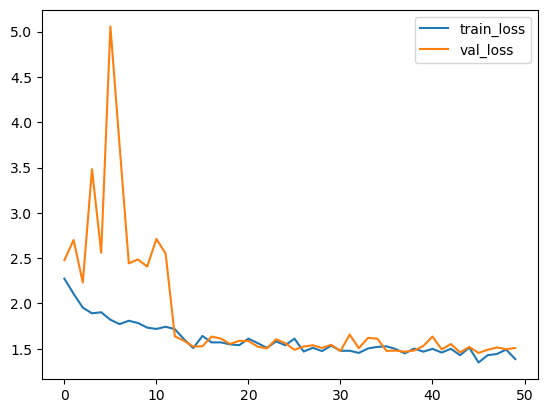

In [57]:
df = pd.read_csv('./training_unet/t_5/train_logs/version_4/metrics.csv')
df = df.groupby(['epoch']).max().reset_index()
plt.plot(df['epoch'], df['train_loss'], label='train_loss')
plt.plot(df['epoch'], df['val_loss'], label='val_loss')
plt.legend()
plt.show()

## Eval

In [47]:
model = UNETModel.load_from_checkpoint(
  './training_unet/t_5/last-v1.ckpt',
  image_size=in_image_size,
	cmap=seg_map_cmap,
	lr=lr,
	epochs=epochs,
).to('cuda')
model.eval()
print(model.device)

cuda:0


In [48]:
datamodule.setup('test')
dataloader= datamodule.test_dataloader()
iterator = iter(dataloader)

In [51]:
# TODO - Adapt
with torch.no_grad():
	batch = next(iterator)
	images = batch['image']
	masks = batch['mask']
	pred_masks = model(images.to('cuda'))
	decoded_pred_mask = pred_masks.log_softmax(dim=1).exp()

for image, mask, pred_mask in zip(images, masks, pred_masks):
	decoded_mask = invserse_cmap(mask.squeeze(), seg_map_cmap)
	decoded_pred = invserse_cmap(decoded_pred.cpu(), seg_map_cmap)
	
	
	plot_images(
		base_plot_size=2,
		original=v2.ToPILImage(mode='RGB')(image/255),
		target = v2.ToPILImage(mode='RGB')(decoded_mask/255),
		pred = v2.ToPILImage(mode='RGB')(decoded_pred/255),
		overlay_tuples=[['original', 'target'], ['original', 'pred']]
	)

NameError: name 'decoded_pred' is not defined

In [65]:
decoded_pred_mask[0].shape

torch.Size([6, 256, 256])

In [53]:
pred_mask.squeeze

torch.Size([6, 256, 256])

In [186]:
pred_masks.log_softmax(dim=1).exp()

RuntimeError: "host_softmax" not implemented for 'Long'

In [176]:
pred_masks.shape

torch.Size([16, 6, 256, 256])

In [144]:
pred_mask.shape

torch.Size([6, 256, 256])

In [142]:
F.softmax(pred_mask, dim=1).permute(1,2,0).argmax(dim=2)

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 5, 0],
        [0, 0, 0,  ..., 3, 0, 3],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [3, 3, 3,  ..., 0, 0, 0],
        [5, 2, 2,  ..., 1, 3, 2]], device='cuda:0')

In [141]:
pred_masks

tensor([[[[-5.3593e+03, -9.2821e+02, -6.7060e+03,  ..., -2.3753e+04,
           -8.0676e+03, -7.3988e+03],
          [-1.3870e+04, -1.1924e+04, -1.3351e+04,  ..., -8.1647e+04,
           -4.7918e+04, -4.1276e+04],
          [-1.4814e+04, -2.0849e+04, -2.0617e+04,  ..., -9.1148e+04,
           -6.9680e+04, -4.6119e+04],
          ...,
          [-2.4314e+04, -2.8576e+04, -2.8157e+04,  ..., -7.6454e+04,
           -5.0966e+04, -4.6188e+04],
          [-1.6565e+04, -2.5398e+04, -2.5114e+04,  ..., -6.9500e+04,
           -5.6104e+04, -3.7572e+04],
          [-1.0544e+04, -1.6838e+04, -2.5033e+04,  ..., -4.7172e+04,
           -4.6547e+04, -3.7224e+04]],

         [[-3.9730e+03, -1.1146e+03,  1.3215e+03,  ...,  4.7628e+04,
            4.8597e+04,  4.1572e+04],
          [-2.5706e+02, -6.1654e+02,  4.1626e+03,  ...,  3.0558e+04,
            4.5289e+04,  4.3703e+04],
          [-4.1946e+03, -4.0902e+02, -2.0746e+03,  ...,  1.4009e+04,
            3.5673e+04,  3.0663e+04],
          ...,
     

In [ ]:
v2.

In [76]:
tmp = pred_masks.log_softmax(dim=1).exp()

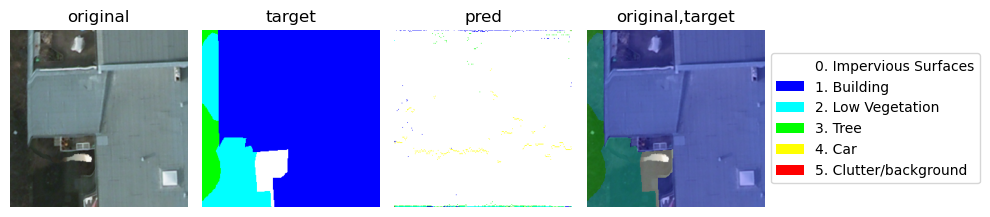

In [182]:
_id = 4

image = images[_id]
mask = masks[_id]
decoded_mask = invserse_cmap(mask.squeeze(), seg_map_cmap)


pred_mask = pred_masks[_id].permute(1,2,0).softmax(dim=-1).argmax(dim=-1).cpu()
dcoded_pred = invserse_cmap(pred_mask.squeeze(0), seg_map_cmap)

plot_images(
	base_plot_size=2.5,
	original=v2.ToPILImage(mode='RGB')(image/255),
	target = v2.ToPILImage(mode='RGB')(decoded_mask/255),
	pred = v2.ToPILImage(mode='RGB')(decoded_pred/255),
  overlay_tuples=[['original', 'target']],
  cmap_labels=seg_map_cmap_labels
)

In [169]:
pred_masks[_id].softmax(dim=-1)# .argmax(dim=-1)

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 1.],
         [0., 0., 0.,  ..., 0., 0., 1.],
         [1., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.],
         [0., 0., 0.,  ..., 0., 1., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 1.],
         [0., 0., 0.,  ..., 0., 0., 1.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]],

        [[1., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 

In [137]:
pred_masks[_id].shape   #.permute(1,2,0).log_softmax(dim=1).exp()

torch.Size([6, 256, 256])

In [147]:
pred_mask

tensor([[4, 4, 4,  ..., 4, 4, 4],
        [4, 4, 4,  ..., 4, 4, 4],
        [4, 4, 4,  ..., 4, 4, 4],
        ...,
        [4, 4, 4,  ..., 4, 4, 4],
        [4, 4, 4,  ..., 4, 4, 4],
        [4, 4, 4,  ..., 4, 4, 4]])